In [16]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from tqdm import trange
from astropy.table import Table, vstack, unique, join
from astropy import units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
from astropy.cosmology import Planck18
from astropy.io import fits
from astropy.wcs import WCS

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist, save_cutouts
from desi_lowz_funcs import find_objects_nearby, process_img, sdss_rgb

# %load_ext autoreload
# %autoreload 2

In [17]:
import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.45   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.1   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar
    

In [18]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")

In [129]:
ras_bad_rchisq = np.array([
    325.77828715625105,
    137.33639489452136,
    127.68492588941022,
    161.24081749569075,    
    230.5611911416743,
    136.7128109117229
])


decs_bad_rchisq = [
    23.379120576982093,
    -1.7893384723768473,
    2.4321683794488527,
    3.886996381136422,
    31.47569235750885,
    77.64959217747678
]

    # 46.021750816066934,    -13.365773525656
    #  65.20590404113857,  -13.733522134796548,
# 5.720770547145609, 7.224984949195506,
temp_dict = {"RA":ras_bad_rchisq, "DEC":decs_bad_rchisq}

bad_rchi_cat = Table(temp_dict)

idx,d2d,_ = match_c_to_catalog(c_cat=bad_rchi_cat, catalog_cat=data_cat,c_ra="RA",c_dec="DEC",catalog_ra="RA_TARGET",catalog_dec="DEC_TARGET")

print(d2d.arcsec)

plot_cat_1 = data_cat[idx]

[0. 0. 0. 0. 0. 0.]


In [130]:
print(len(plot_cat_1))

6


In [143]:
# plot_sizes = len(plot_ras) * [90]

# plot_sizes[-5] = 180

# plot_sizes[-9] = 180

plot_ras = [
    146.009,
    221.045,
    357.972,
    116.380, 
    132.908,
    149.19097155933508, #237.319, 	
    337.099,
    178.868,
    202.407,
    210.234,
    11.391,
    211.333,
    135.066,
    153.766,
    116.380
]

plot_decs = [
    -0.645,
    0.183,
    0.757,
    71.217,
    -2.354,
    28.826504596164543, #21.832,
    30.293,
    57.664,
    26.423,
    41.009,
    -1.101,
    10.413,
    35.720,
    43.007,
    71.217
]

temp_dict2 = {"RA":plot_ras, "DEC":plot_decs}

sga_miss_cat = Table(temp_dict2)

idx_2,d2d_2,_ = match_c_to_catalog(c_cat=sga_miss_cat, catalog_cat=data_cat,c_ra="RA",c_dec="DEC",catalog_ra="RA_TARGET",catalog_dec="DEC_TARGET")

print(d2d_2.arcsec)

plot_cat_2 = data_cat[idx_2][d2d_2.arcsec < 10]

[  1.11782227   0.85336119 507.36920598   0.86266108  41.44025424
   8.63191873   1.93111437   1.61619641 166.87909693 372.09237771
   1.2350232    1.09576355 205.48058017   1.82659763   0.86266108]


In [144]:
print(len(plot_cat_1), len(plot_cat_2))

plot_cat =  vstack([plot_cat_1, plot_cat_2])

6 10


In [145]:
##get the image path for these objects and then join!!

def matching_image_paths(target_cat, img_table):

    print(f"Initial catalog size = {len(target_cat)}")
    
    # join to get image paths for OG objects
    matched_cat = join(
        target_cat,
        img_table,
        keys="TARGETID",
        join_type="inner"
    )

    print(f"Objects with images = {len(matched_cat)}")

    return matched_cat


bgsb_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]
sga_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_SGA_sga_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]
elg_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_ELG_shreds_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]
bgsf_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_FAINT_shreds_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]

tot_shred_temp = vstack([bgsb_shred, sga_shred, elg_shred, bgsf_shred])
tot_shred_temp = unique(tot_shred_temp, keys="TARGETID")

##get the matching image paths for just data_cat_og
plot_cat = matching_image_paths(plot_cat, tot_shred_temp)

tgids_dwarfy = np.array([39627666902485913, 39627642944618581, 39627643653460508, 39627666898293590, 39633005240650807, 39633262703807751, 
39627740013401179, 39627790391187481, 39627636309230897, 39627335137233103, 39627757658834857, 39628377929290386])

dwarfy_mask = np.isin(data_cat["TARGETID"].data, tgids_dwarfy)
plot_dwarfy = data_cat[dwarfy_mask]

plot_dwarfy = matching_image_paths(plot_dwarfy, tot_shred_temp)

print(len(plot_dwarfy))
print(len(plot_cat))

plot_cat = vstack([plot_dwarfy, plot_cat])

print(len(plot_cat))


Initial catalog size = 16
Objects with images = 16
Initial catalog size = 12
Objects with images = 12
12
16
28


In [146]:
print(len(plot_cat))


28


In [147]:
## make the multi-panel plot now!!!

from desi_lowz_funcs import process_img, match_c_to_catalog
from matplotlib.patches import Ellipse


def plot_ellipse(ax, aper_xcen, aper_ycen, scale_f, r50_pix, ba_ratio, phi_deg, edgecolor, lw, ls, alpha):
    ell = Ellipse((aper_xcen, aper_ycen), 2 * scale_f * r50_pix, 2 * scale_f * r50_pix * ba_ratio, angle=phi_deg - 90,
                  facecolor='none', edgecolor=edgecolor, lw=lw, ls=ls, alpha=alpha)
    ax[0].add_patch(ell)
    return

def draw_label_line(ax, line_start, line_y, color, ls, alpha, lw = 2):
    # line_start = 0.25 - offset
    # line_y = yloc - 0.09
    ax[0].plot([line_start -0.1, line_start+0.1], [line_y,line_y],
               color = color,ls=ls, alpha=alpha, lw = lw,
              transform=ax[0].transAxes)
    return
    
def plot_one_panel(ax,targetid, new_cat,
                  alpha=0.75,linewidth=1,
                  new_ls = "-", new_color = "white",
                    trac_ls  = (0,(1,1)), trac_color="greenyellow",
                  scale_f = 2, cutout_size_arcsec = 60,
                  bar_size_arc=30, bar_size_str="30''", text_multicolor=False):
    '''
    Function that plots a cutout and our new aperture on it!!
    '''

    index = np.where(new_cat["TARGETID"] == targetid)[0][0]

    #get the 3 different photometry!!
    g_org, r_org, z_org = new_cat[index]["MAG_G_TARGET"], new_cat[index]["MAG_R_TARGET"], new_cat[index]["MAG_Z_TARGET"]
    g_new, r_new, z_new = new_cat[index]["MAG_G"], new_cat[index]["MAG_R"], new_cat[index]["MAG_Z"]

    #get image and wcs infno
    img_path = new_cat[index]["IMAGE_PATH"]
    hdus = fits.open(img_path)
    img_data = hdus[0].data
    wcs = WCS(fits.getheader( img_path))
    
    ##get the final,updated ra,dec of the galaxy
    ra_new, dec_new = new_cat["RA"].data[index], new_cat["DEC"].data[index]
    zred = new_cat["Z"].data[index]
    
    ##INFO ON NEW APERTURE
    aper_xcen, aper_ycen,_ = wcs.all_world2pix(ra_new,dec_new,0,1)
    aper_params = new_cat["SHAPE_PARAMS"].data[index]
    r50_new = new_cat["R50_R"].data[index]/0.262 #need to convert from pixels to arcseconds

    #INFO ON TRACTOR APERTURE
    ra_tgt, dec_tgt = new_cat["RA_TARGET"].data[index], new_cat["DEC_TARGET"].data[index]
    trac_xcen, trac_ycen,_ = wcs.all_world2pix(ra_tgt,dec_tgt,0,1)
    r50_trac = new_cat["SHAPE_R"].data[index] / 0.262
    if r50_trac == 0:
        r50_trac = 0.75/0.262

    trac_ba = new_cat["BA"].data[index]
    trac_phi = new_cat["PHI"].data[index]
    
    #finalize the cutout size
    cutout_size_pix  = int(cutout_size_arcsec/0.262)

    cutout_size_pix = np.minimum(cutout_size_pix, img_data.shape[1])
   
    #get the cutout image
    rgb_img, shift = process_img(img_data, cutout_size = cutout_size_pix, org_size = np.shape(img_data)[1], return_shift=True )

    #however, once we do the rescaling of image, we need to shift the x_center, y_center

    trac_xcen -= shift
    trac_ycen -= shift

    aper_xcen -= shift
    aper_ycen -= shift

    fsize = 14
    fs_title = 13
    fs_col = "white"
    yloc = 0.97

    if text_multicolor is False:
        ax[0].text(0.69, 0.125, f"({ra_new:.3f},{dec_new:.3f})", transform=ax[0].transAxes, va='top',ha="center",color=fs_col,fontsize = 8.5)
    else:
        ra_str = f"{ra_new:.3f}"
        dec_str = f"{dec_new:.3f}"
        full_str = f"({ra_str},{dec_str})"
        
        # Split into "black" part and "white" part
        n_black = 4  # however many leading chars you want black
        black_part = full_str[:n_black]
        white_part = full_str[n_black:]
        
        # Draw white part first (full string), then overlay black part on top
        ax[0].text(0.69, 0.125, full_str, transform=ax[0].transAxes,
                   va='top', ha='center', color=fs_col, fontsize=8.5)
        ax[0].text(0.635, 0.125, black_part + " " * len(white_part),
                   transform=ax[0].transAxes, va='top', ha='center',
                   color='black', fontsize=8.5)


    ax[0].imshow(rgb_img, origin="lower",rasterized=True)

    offset = 0.15
    ax[0].text(0.5 - offset - 0.075,yloc,rf"$r_{{\rm DR9}}$:{r_org:.1f}",
               transform=ax[0].transAxes, va='top',ha="center",color = trac_color,alpha=alpha+0.2,fontsize = 10)

    ax[0].text(0.5 + offset + 0.075,yloc,rf"$r_{{\rm new}}$:{r_new:.1f}",
               transform=ax[0].transAxes, va='top',ha="center",color = new_color,alpha=alpha+0.2,fontsize = 10)
        
    #draw a line right underneath this to show
    if True:
        draw_label_line(ax, 0.5 - offset - 0.075, yloc - 0.12, trac_color, trac_ls, alpha,lw = linewidth + 0.5)
        draw_label_line(ax, 0.5 + offset + 0.075 , yloc - 0.12, new_color, new_ls, alpha, lw = linewidth)
        
    ##plot the new aperture
    plot_ellipse(ax, aper_xcen, aper_ycen, scale_f, r50_new, aper_params[0], aper_params[1], new_color, linewidth, new_ls, alpha=1)

    #plot the tractor aperture
    plot_ellipse(ax, trac_xcen, trac_ycen, scale_f, r50_trac, trac_ba, trac_phi, trac_color, linewidth+0.5, trac_ls, alpha)

    for axi in ax:
        axi.set_xticks([])
        axi.set_yticks([])
        axi.set_xlim([0,np.shape(rgb_img)[1]])
        axi.set_ylim([0,np.shape(rgb_img)[1]])
        
    #plot the horizontal bar plotting 30''

    bar_size = bar_size_arc/0.262
    bar_start = 0.05*np.shape(rgb_img)[0]
    y_bar = 0.07*np.shape(rgb_img)[0]
    
    ax[0].plot([bar_start, bar_start+bar_size], [y_bar,y_bar],color = "white",lw = 1)

    if bar_size_str is not None:
        ax[0].text( bar_start + 0.55*bar_size, y_bar*1.2, f"{bar_size_str}",color = "white",ha="center",fontsize =  9)
            
    return ax
    

In [148]:
len(plot_cat)

28

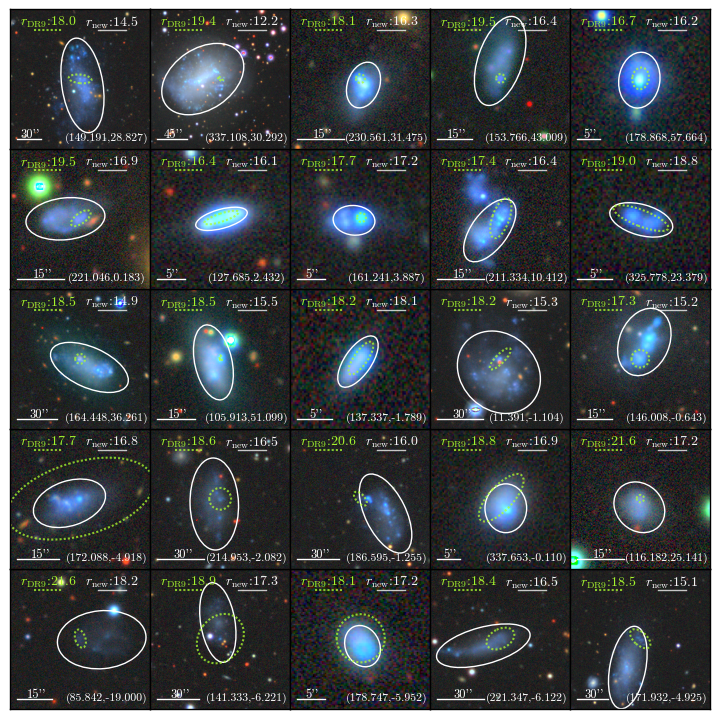

In [157]:
fig,ax = make_subplots(ncol=5,nrow=5,return_fig=True,col_spacing=0,row_spacing=0,
                      plot_size = 1.4)

cutouts = [60]*len(plot_cat)


####

cutouts[12+0] = 20
cutouts[12+1] = 105
cutouts[12+2] = 60
cutouts[12+3] = 45
cutouts[12+4] = 25
cutouts[12+5] = 25

cutouts[12+6] = 45
cutouts[12+7] = 20
cutouts[12+8] = 175
cutouts[12+9] = 210
cutouts[12+10] = 45
cutouts[12+11] = 60

cutouts[12+12] = 30
# cutouts[12+13] = 90
# cutouts[12+14] = 75
# cutouts[12+15] = 30
# cutouts[12+16] = 45
# cutouts[12+17] = 45

####
cutouts[0] = 60
cutouts[1] = 100
cutouts[2] = 25
cutouts[3] = 90
cutouts[4] = 135
cutouts[5] = 50

##

cutouts[6] = 90
cutouts[7] = 100
cutouts[8] = 30
cutouts[9] = 45
cutouts[10] = 105

#
cutouts[11] = 55

for i in range(25):

    if cutouts[i] >= 200:
        bar_size = 45
    elif cutouts[i] >= 75:
        bar_size = 30
    elif cutouts[i] >= 45:
        bar_size = 15
    else:
        bar_size = 5


    if i == 19:
        text_mult = False
    else:
        text_mult=False
    
    plot_one_panel([ax[i]],plot_cat["TARGETID"][i], plot_cat,
                      alpha=0.75,linewidth=1,
                      new_ls = "-", new_color = "white",
                        trac_ls  = (0,(1,1)), trac_color="greenyellow",
                      scale_f = 2, cutout_size_arcsec = cutouts[i],
                      bar_size_arc=bar_size, bar_size_str=f"{bar_size}''", text_multicolor=text_mult)


for axi in ax:
    axi.set_xticks([])
    axi.set_yticks([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_catalog_visuals.pdf")

plt.show()

In [15]:
def hires_cutout(ax,targetid, new_cat, cutout_size_arcsec):
    '''
    Function that plots a cutout and our new aperture on it!!
    '''

    index = np.where(new_cat["TARGETID"] == targetid)[0][0]

    #get the 3 different photometry!!

    #get image and wcs infno
    img_path = new_cat[index]["IMAGE_PATH"]
    hdus = fits.open(img_path)
    img_data = hdus[0].data
    wcs = WCS(fits.getheader( img_path))
    
    #finalize the cutout size
    cutout_size_pix  = int(cutout_size_arcsec/0.262)

    cutout_size_pix = np.minimum(cutout_size_pix, img_data.shape[1])
   
    #get the cutout image
    rgb_img, shift = process_img(img_data, cutout_size = cutout_size_pix, org_size = np.shape(img_data)[1], return_shift=True )

    ax[0].imshow(rgb_img, origin="lower")

    for axi in ax:
        axi.set_xticks([])
        axi.set_yticks([])
        axi.set_xlim([0,np.shape(rgb_img)[1]])
        axi.set_ylim([0,np.shape(rgb_img)[1]])
        
    return ax
    

In [33]:
## for all these objects let us save high-res cutouts of these

for i in range(len(plot_cat)):
    fig,ax = make_subplots(ncol=1,nrow=1,return_fig=True,plot_size=4)
    
    if cutouts[i] >= 75:
        bar_size = 30
    elif cutouts[i] >= 45:
        bar_size = 15
    else:
        bar_size = 5
    
    hires_cutout([ax[0]],plot_cat["TARGETID"][i], plot_cat, cutout_size_arcsec = cutouts[i] * 1.5 )

    plt.savefig(f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_{i}.jpg",bbox_inches="tight",dpi=300)
    
    plt.close()

In [30]:
plot_cat[14]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IMAGE_PATH,SHAPE_R,BA,PHI
,,,,,,,,deg,deg,deg,deg,,Mpc,,,mag,mag,mag,mag,mag,mag,,,,,,,,,,,
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes10,int32,bytes13,bool,float32,float32[2],bool,bytes122,float32,float32,float32
39627769058951413,main,bright,27199,0.004846564883987,125117.68798027933,False,0.005990894391218138,146.00838091432524,-0.64274417673528,146.0088727980158,-0.6447167407608649,DESI J146.0088-00.6447,23.185415,7.9447513,8.104648,15.252567,15.209373,15.370726,17.22498,17.327793,17.59952,BGS_BRIGHT,0,COG,True,7.4967613,0.701928 .. 156.3761,True,/pscratch/sd/v/virajvm/redo_photometry_plots/all_sga_cutouts/image_tgid_39627769058951413_ra_146.009_dec_-0.645.fits,1.8909734,1.0,0.0


In [31]:
from desi_lowz_funcs import save_jpg
import requests

In [32]:
session = requests.Session()

In [34]:
save_jpg(146.0177, -0.6501, f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_large.jpg", session, size = 1300)


In [35]:
save_jpg(132.9067, -2.3629, f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_large_2.jpg", session, size = 1000)


In [36]:


save_jpg(357.9682, 0.7554, f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_large_3.jpg", session, size = 500)


## save the two cutouts one with tractor sources on top of it!!

In [4]:
temp = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")


In [51]:
temp[temp["TARGETID"]== 39627752084603161]["FILE_PATH"]

/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds/south/sweep-210m005-220p000/2143m015/BGS_BRIGHT_tgid_39627752084603161


In [19]:
data_cat[data_cat["TARGETID"] == 39627752084603161]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39627752084603161,main,bright,25917,0.00508421957175602,2128.7520497860387,0,0.0059386029650703165,214.26470371292584,-1.5041126410430765,214.26114134541552,-1.5044084469165917,DESI J214.2611-01.5044,19.946979522705078,7.517096996307373,0.11775110959065732,16.351707458496094,16.23963737487793,16.158233642578125,18.744047164916992,18.608434677124023,18.700334548950195,BGS_BRIGHT,0,0,COG,True,16.113250732421875,0.5455299615859985 .. 101.0338363647461,False,[39627752084603161 39627752084603180 39627752084603243 39627752084603392],39627752084603180,False,CF3_NAM,39627752084603161


In [11]:
img_hdus = fits.open("/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds_cutouts/image_tgid_39627752084603161_ra_214.261_dec_-1.504.fits")
source_cat_f = Table.read("/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds/south/sweep-210m005-220p000/2143m015/BGS_BRIGHT_tgid_39627752084603161/source_cat_f_more.fits")



In [57]:
img_hdus[0].data.shape

(3, 1229, 1229)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord


TYPE_COLORS = {
    'PSF': 'lime',
    'REX': 'orange',
    'EXP': 'deepskyblue',
    'DEV': 'violet',
    'SER': 'magenta',
    'DUP': 'gray',
}


def tractor_ellipse_params(shape_r, shape_e1, shape_e2, pixscale=0.262):
    """
    Convert Tractor (shape_r, e1, e2) to matplotlib Ellipse parameters.

    Returns
    -------
    width_pix, height_pix : arrays
        Full axis lengths (2a, 2b) in pixels for matplotlib.patches.Ellipse.
    angle_deg : array
        Rotation of the width axis CCW from +x, in degrees.

    Notes
    -----
    Tractor / Legacy Surveys convention:
        |e|   = sqrt(e1^2 + e2^2)
        b/a   = (1 - |e|) / (1 + |e|)
        phi   = 0.5 * arctan2(e2, e1)   [position angle, North through East]

    For a Legacy Surveys cutout (North up, East left), the major axis at PA=0
    points along +y (North).  matplotlib's Ellipse `angle` rotates the WIDTH
    axis CCW from +x, so:

        angle = 90 deg + phi
    """
    e1 = np.asarray(shape_e1, dtype=float)
    e2 = np.asarray(shape_e2, dtype=float)
    r  = np.asarray(shape_r,  dtype=float)

    abs_e = np.sqrt(e1**2 + e2**2)
    abs_e = np.clip(abs_e, 0.0, 0.999)
    ba = (1.0 - abs_e) / (1.0 + abs_e)

    phi_rad = 0.5 * np.arctan2(e2, e1)  # PA, radians, N through E

    a_pix = r / pixscale
    b_pix = a_pix * ba

    width_pix  = 2.0 * a_pix              # matplotlib "width"  = major axis
    height_pix = 2.0 * b_pix              # matplotlib "height" = minor axis
    angle_deg  = 90.0 + np.degrees(phi_rad)

    return width_pix, height_pix, angle_deg


def plot_tractor_sources(ax, source_cat, wcs,
                         pixscale=0.262, lw=0.4, alpha=0.95,
                         min_radius_pix=2.0, scale_radius=1.0,
                         highlight_ra=None, highlight_dec=None,
                         type_colors=None):
    """Overlay Tractor sources as ellipses on an image axis."""
    if type_colors is None:
        type_colors = TYPE_COLORS

    ras   = np.asarray(source_cat['ra'])
    decs  = np.asarray(source_cat['dec'])
    types = np.array([str(t).strip().upper() for t in source_cat['type']])

    shape_r  = np.asarray(source_cat['shape_r'])  if 'shape_r'  in source_cat.colnames else np.zeros(len(source_cat))
    shape_e1 = np.asarray(source_cat['shape_e1']) if 'shape_e1' in source_cat.colnames else np.zeros(len(source_cat))
    shape_e2 = np.asarray(source_cat['shape_e2']) if 'shape_e2' in source_cat.colnames else np.zeros(len(source_cat))

    xpix, ypix = wcs.all_world2pix(ras, decs, 0)

    width_pix, height_pix, angle_deg = tractor_ellipse_params(
        shape_r, shape_e1, shape_e2, pixscale=pixscale)

    # Apply visual scaling on the radius
    width_pix  *= scale_radius
    height_pix *= scale_radius

    # PSF / zero-radius -> small circles
    point_like = (width_pix < 2 * min_radius_pix) | (~np.isfinite(width_pix))
    width_pix  = np.where(point_like, 2 * min_radius_pix, width_pix)
    height_pix = np.where(point_like, 2 * min_radius_pix, height_pix)
    angle_deg  = np.where(point_like, 0.0, angle_deg)

    highlight_idx = None
    if highlight_ra is not None and highlight_dec is not None:
        seps = SkyCoord(highlight_ra, highlight_dec, unit='deg').separation(
            SkyCoord(ras, decs, unit='deg')).arcsec
        highlight_idx = int(np.argmin(seps))

    for i in range(len(source_cat)):
        if i == highlight_idx:
            continue
        c = "lightgrey"
        ax.add_patch(Ellipse((xpix[i], ypix[i]),
                             width_pix[i], height_pix[i],
                             angle=angle_deg[i],
                             facecolor='none', edgecolor=c,
                             lw=lw, alpha=alpha))

    if highlight_idx is not None:
        i = highlight_idx
        ax.add_patch(Ellipse((xpix[i], ypix[i]),
                             width_pix[i], height_pix[i],
                             angle=angle_deg[i],
                             facecolor='none', edgecolor='white', lw=1.5, ls = "-"))


def plot_image_with_tractor(img_path, source_cat_path,
                            ra=None, dec=None,
                            cutout_size_arcsec=40, pixscale=0.262,
                            scale_radius=1.0, figsize=(7, 7),
                            ax=None, title=None,
                            show_legend=True, show_scalebar=True):
    """Open a Legacy Surveys cutout FITS and overlay Tractor source ellipses."""
    hdul = fits.open(img_path)
    data = hdul[0].data            # (3, H, W) in g, r, z
    header = hdul[0].header
    wcs = WCS(header)
    if wcs.naxis > 2:
        wcs = wcs.celestial

    rgb = sdss_rgb([data[0], data[1], data[2]], ['g', 'r', 'z'],
                   scales=dict(g=(2, 6.0), r=(1, 3.4), z=(0, 2.2)), m=0.03)

    H, W = rgb.shape[:2]
    if ra is None or dec is None:
        cx, cy = W / 2.0, H / 2.0
    else:
        cx, cy = wcs.all_world2pix(ra, dec, 0)

    half_pix = 0.5 * cutout_size_arcsec / pixscale

    x0 = max(0, int(np.floor(cx - half_pix)))
    x1 = min(W, int(np.ceil(cx + half_pix)))
    y0 = max(0, int(np.floor(cy - half_pix)))
    y1 = min(H, int(np.ceil(cy + half_pix)))
    bbox = (x0, x1, y0, y1)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb, origin='lower')

    source_cat = Table.read(source_cat_path)
    plot_tractor_sources(ax, source_cat, wcs,
                         pixscale=pixscale, scale_radius=scale_radius,
                         highlight_ra=214.26114134541552, highlight_dec=-1.5044084469165917)

    ax.set_xlim(cx - half_pix, cx + half_pix)
    ax.set_ylim(cy - half_pix, cy + half_pix)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

    return ax, source_cat, wcs, bbox

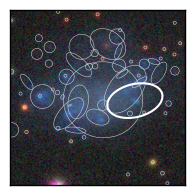

In [59]:
img_path  = "/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds_cutouts/image_tgid_39627752084603161_ra_214.261_dec_-1.504.fits"
cat_path  = "/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds/south/sweep-210m005-220p000/2143m015/BGS_BRIGHT_tgid_39627752084603161/source_cat_f_more.fits"

ax = make_subplots(ncol=1,nrow=1,plot_size = 1.75, row_spacing=0,col_spacing=0)

_, cat, wcs, bbox = plot_image_with_tractor(
    img_path, cat_path,
    ra=214.2647037129258, dec=-1.50411264104,
    cutout_size_arcsec=60,
    scale_radius=1.0, ax= ax[0]        # try 2-3 if ellipses look too small
)


plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/shred_eg.pdf")

plt.show()

In [50]:
## then we plot the final image!! with the final image and aperture?

In [52]:
final_img_path = np.load("/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds/south/sweep-210m005-220p000/2143m015/BGS_BRIGHT_tgid_39627752084603161/final_reconstruct_galaxy_subfunction_no_isolate.npy")



In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_single_aperture(img_arr, ra, dec,
                         r50_pix, ba_ratio, phi_deg,
                         wcs=None, bbox=None,
                         pixscale=0.262, cutout_size_arcsec=40,
                         scale_f=2.0,
                         aperture_color='white', lw=1.5, ls='-', alpha=1.0,
                         figsize=(6, 6), ax=None,
                         rgb_scales=None, m=0.03,
                         show_scalebar=True, bar_size_arcsec=15.0,
                         title=None):
    if rgb_scales is None:
        rgb_scales = dict(g=(2, 6.0), r=(1, 3.4), z=(0, 2.2))

    rgb = sdss_rgb([img_arr[0], img_arr[1], img_arr[2]],
                   ['g', 'r', 'z'], scales=rgb_scales, m=m)

    if bbox is not None:
        if wcs is None:
            raise ValueError("bbox given but wcs is None.")
        x0, x1, y0, y1 = bbox
        rgb = rgb[y0:y1, x0:x1]                    # <-- the line that was missing
        cx, cy = wcs.all_world2pix(ra, dec, 0)
        ap_x = cx - x0
        ap_y = cy - y0
        bbox_out = bbox
    else:
        if wcs is None:
            raise ValueError("Need wcs (and optionally bbox).")
        full_H, full_W = img_arr.shape[1], img_arr.shape[2]
        cx, cy = wcs.all_world2pix(ra, dec, 0)
        half_pix = 0.5 * cutout_size_arcsec / pixscale
        x0 = max(0, int(np.floor(cx - half_pix)))
        x1 = min(full_W, int(np.ceil(cx + half_pix)))
        y0 = max(0, int(np.floor(cy - half_pix)))
        y1 = min(full_H, int(np.ceil(cy + half_pix)))
        rgb = rgb[y0:y1, x0:x1]
        ap_x = cx - x0
        ap_y = cy - y0
        bbox_out = (x0, x1, y0, y1)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb, origin='lower')

    width  = 2 * scale_f * r50_pix
    height = 2 * scale_f * r50_pix * ba_ratio
    ax.add_patch(Ellipse((ap_x, ap_y), width, height,
                         angle=phi_deg - 90,
                         facecolor='none', edgecolor=aperture_color,
                         lw=lw, ls=ls, alpha=alpha))

    ax.set_xlim(0, rgb.shape[1])
    ax.set_ylim(0, rgb.shape[0])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

    if title:
        ax.set_title(title)

    return ax, bbox_out

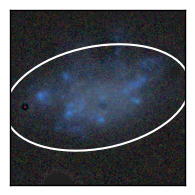

In [78]:
final_img_arr = np.load(
    "/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds/south/"
    "sweep-210m005-220p000/2143m015/BGS_BRIGHT_tgid_39627752084603161/"
    "final_reconstruct_galaxy_subfunction_no_isolate.npy"
)

# get the row in new_cat for this target
index = np.where(data_cat["TARGETID"] == 39627752084603161)[0][0]

ra_new    = data_cat["RA"][index]
dec_new   = data_cat["DEC"][index]
r50_new   = data_cat["R50_R"][index] / 0.262   # arcsec -> pixels, like your code
aper_params = data_cat["SHAPE_PARAMS"][index]  # (ba_ratio, phi_deg)

ax = make_subplots(ncol=1,nrow=1,plot_size = 1.75, row_spacing=0,col_spacing=0)

# wcs + bbox come from the prior call to plot_image_with_tractor
plot_single_aperture(
    final_img_arr,
    ra=ra_new, dec=dec_new,
    r50_pix=r50_new,
    ba_ratio=aper_params[0],
    phi_deg=aper_params[1],
    wcs=wcs, bbox=bbox,
    scale_f=2.0,
    aperture_color='white',
    lw=1.5,ax=ax[0]
)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/post_shred_eg.pdf")

plt.show()